In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

In [ ]:
df = pd.read_csv("phishing.csv")

print("Dataset loaded successfully!")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

FileNotFoundError: [Errno 2] No such file or directory: '/content/phishing.csv'

In [ ]:
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [ ]:
df.describe()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
count,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,...,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000,11054.000000
mean,5526.500000,0.313914,-0.633345,0.738737,0.700561,0.741632,-0.734938,0.064049,0.251040,-0.336711,...,0.613353,0.816899,0.061335,0.377239,0.287407,-0.483626,0.721549,0.343948,0.719739,0.113986
std,3191.159272,0.949495,0.765973,0.674024,0.713625,0.670837,0.678165,0.817492,0.911856,0.941651,...,0.789845,0.576807,0.998162,0.926158,0.827680,0.875314,0.692395,0.569936,0.694276,0.993527
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2763.250000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5526.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8289.750000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11053.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(df.isnull().sum())

Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64


In [ ]:
print(df["class"].value_counts())

class
 1    6157
-1    4897
Name: count, dtype: int64


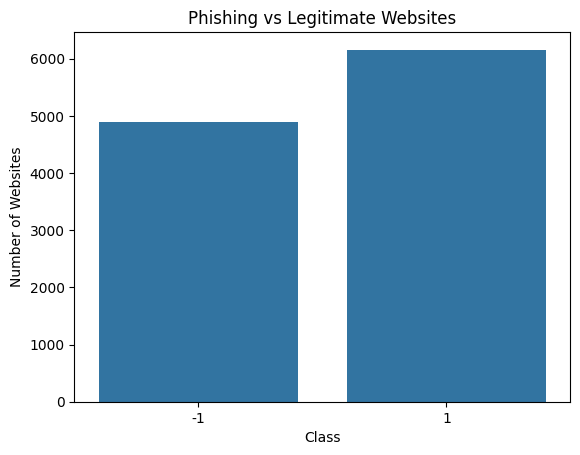

In [ ]:
sns.countplot(x=df["class"])

plt.title("Phishing vs Legitimate Websites")
plt.xlabel("Class")
plt.ylabel("Number of Websites")

plt.show()

In [ ]:
X = df.drop(columns=["class"])

y = df["class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (11054, 31)
Target: (11054,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8843
Testing samples: 2211


In [ ]:
f_scores, p_values = f_classif(X_train, y_train)

feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

feature_scores = feature_scores.sort_values(
    by="F_Score",
    ascending=False
)

feature_scores.head(26)

,Feature,F_Score,P_Value
8,HTTPS,9017.353813,0.000000e+00
14,AnchorURL,8139.392330,0.000000e+00
6,PrefixSuffix-,1224.620090,2.180502e-251
26,WebsiteTraffic,1169.665513,7.201642e-241
7,SubDomains,888.551354,3.917460e-186
13,RequestURL,605.323827,2.424710e-129
15,LinksInScriptTags,560.222950,3.875125e-120
9,DomainRegLen,477.687837,3.544395e-103
16,ServerFormHandler,470.811454,9.325778e-102
24,AgeofDomain,146.729038,1.655902e-33


In [ ]:
selected_features = feature_scores.head(26)["Feature"].tolist()

print("Selected Features:")
print(selected_features)

Selected Features:
['HTTPS', 'AnchorURL', 'PrefixSuffix-', 'WebsiteTraffic', 'SubDomains', 'RequestURL', 'LinksInScriptTags', 'DomainRegLen', 'ServerFormHandler', 'AgeofDomain', 'GoogleIndex', 'PageRank', 'UsingIP', 'DNSRecording', 'StatsReport', 'ShortURL', 'Symbol@', 'LongURL', 'AbnormalURL', 'StatusBarCust', 'NonStdPort', 'HTTPSDomainURL', 'Redirecting//', 'LinksPointingToPage', 'InfoEmail', 'WebsiteForwarding']


In [ ]:
X_train_selected = X_train[selected_features]

X_test_selected = X_test[selected_features]

print("Training shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

Training shape: (8843, 26)
Testing shape: (2211, 26)


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(
    X_train_selected,
    y_train
)

lr_prediction = lr.predict(X_test_selected)

print("Logistic Regression")
print("-------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_prediction)
)

print(
    "Precision:",
    precision_score(y_test, lr_prediction, average="weighted")
)

print(
    "Recall:",
    recall_score(y_test, lr_prediction, average="weighted")
)

print(
    "F1 Score:",
    f1_score(y_test, lr_prediction, average="weighted")
)

Logistic Regression
-------------------
Accuracy: 0.9389416553595658
Precision: 0.9389151841902168
Recall: 0.9389416553595658
F1 Score: 0.9389048593703287


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_selected,
    y_train
)

dt_prediction = dt.predict(X_test_selected)

print("Decision Tree")
print("-------------")

print(
    "Accuracy:",
    accuracy_score(y_test, dt_prediction)
)

print(
    "Precision:",
    precision_score(y_test, dt_prediction, average="weighted")
)

print(
    "Recall:",
    recall_score(y_test, dt_prediction, average="weighted")
)

print(
    "F1 Score:",
    f1_score(y_test, dt_prediction, average="weighted")
)

Decision Tree
-------------
Accuracy: 0.9638172772501131
Precision: 0.9638271399497392
Recall: 0.9638172772501131
F1 Score: 0.9637933972190099


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_selected,
    y_train
)

rf_prediction = rf.predict(X_test_selected)

In [ ]:
print("Random Forest")
print("-------------")

print(
    "Accuracy:",
    accuracy_score(y_test, rf_prediction)
)

print(
    "Precision:",
    precision_score(y_test, rf_prediction, average="weighted")
)

print(
    "Recall:",
    recall_score(y_test, rf_prediction, average="weighted")
)

print(
    "F1 Score:",
    f1_score(y_test, rf_prediction, average="weighted")
)

Random Forest
-------------
Accuracy: 0.9733152419719584
Precision: 0.9734041125308709
Recall: 0.9733152419719584
F1 Score: 0.9732865981315457


In [ ]:
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       979
           1       0.97      0.98      0.98      1232

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



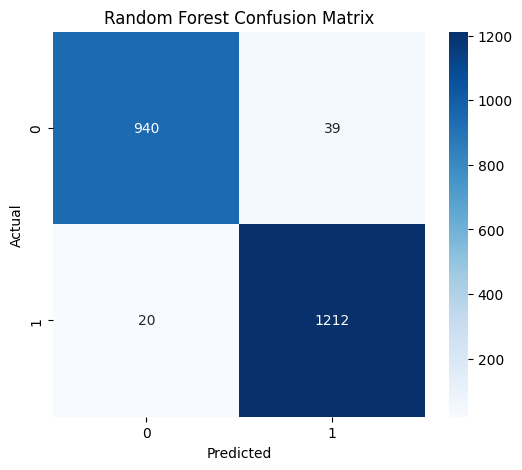

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
0,HTTPS,0.311394
1,AnchorURL,0.260201
3,WebsiteTraffic,0.072218
4,SubDomains,0.061806
2,PrefixSuffix-,0.046124
6,LinksInScriptTags,0.042048
5,RequestURL,0.023345
23,LinksPointingToPage,0.020444
8,ServerFormHandler,0.019804
9,AgeofDomain,0.016775


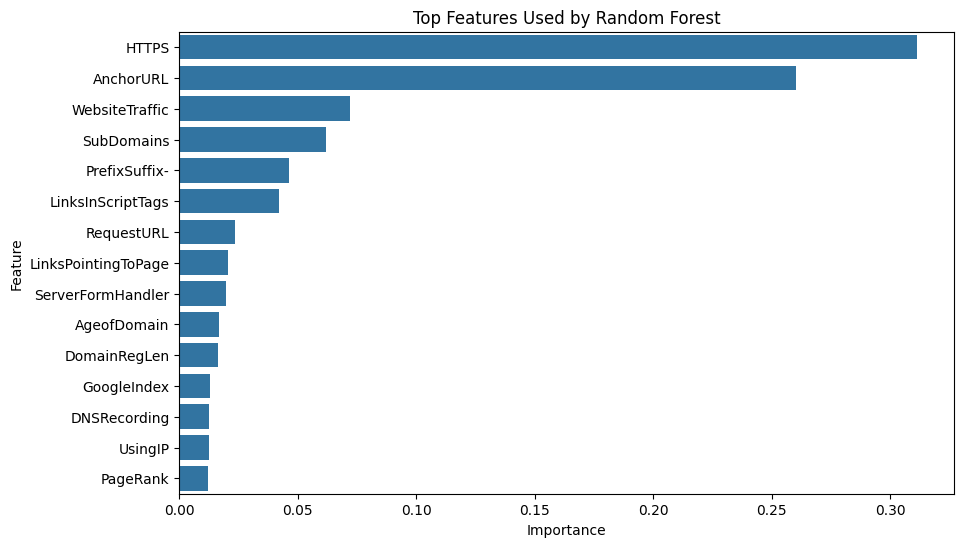

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Used by Random Forest")

plt.show()

In [ ]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction)
    ],

    "Precision": [
        precision_score(y_test, lr_prediction, average="weighted"),
        precision_score(y_test, dt_prediction, average="weighted"),
        precision_score(y_test, rf_prediction, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, lr_prediction, average="weighted"),
        recall_score(y_test, dt_prediction, average="weighted"),
        recall_score(y_test, rf_prediction, average="weighted")
    ],

    "F1": [
        f1_score(y_test, lr_prediction, average="weighted"),
        f1_score(y_test, dt_prediction, average="weighted"),
        f1_score(y_test, rf_prediction, average="weighted")
    ]

})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.938942,0.938915,0.938942,0.938905
1,Decision Tree,0.963817,0.963827,0.963817,0.963793
2,Random Forest,0.973315,0.973404,0.973315,0.973287


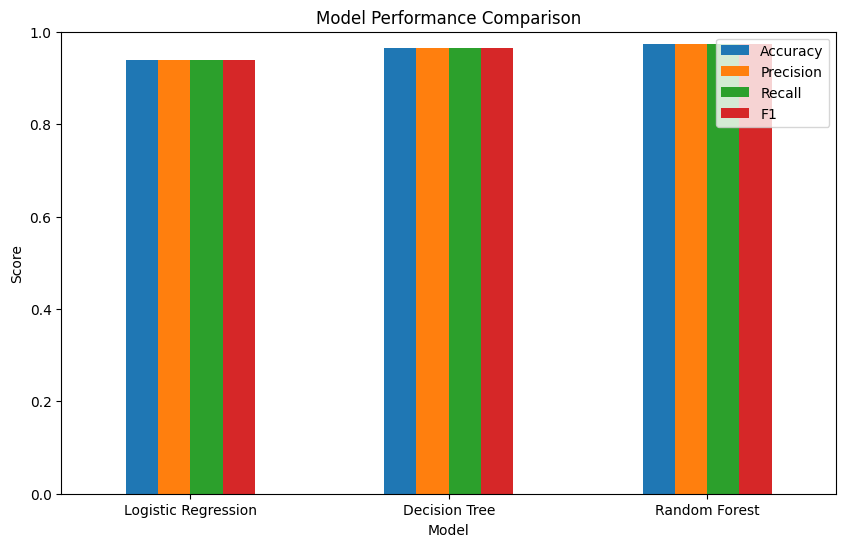

In [ ]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [ ]:
joblib.dump(
    rf,
    "phishing_model.pkl"
)

joblib.dump(
    selected_features,
    "selected_features.pkl"
)

print("Model saved successfully!")

Model saved successfully!
